Iniciando GridSearchCV para SVM RBF (esto tomará más tiempo)...

Mejores parámetros encontrados: {'C': 100, 'gamma': 0.01}
Mejor puntuación de validación cruzada: 0.9714

Reporte de clasificación del SVM RBF optimizado:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Matriz de confusión:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


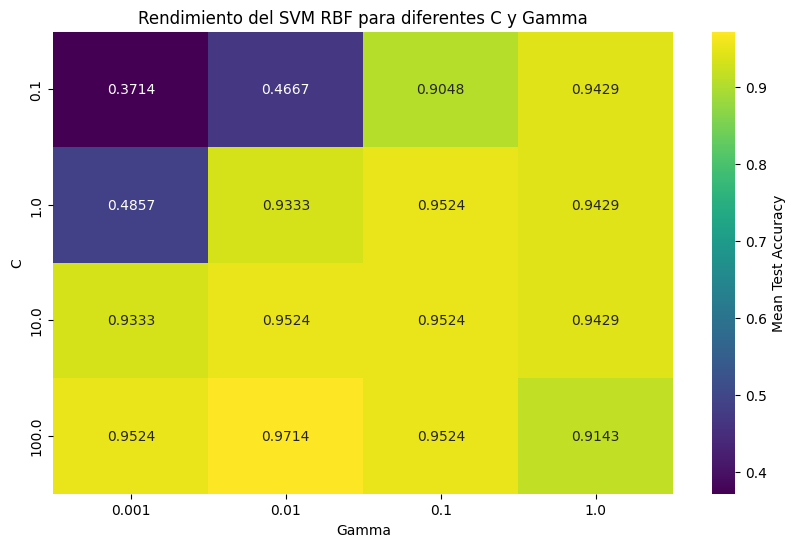

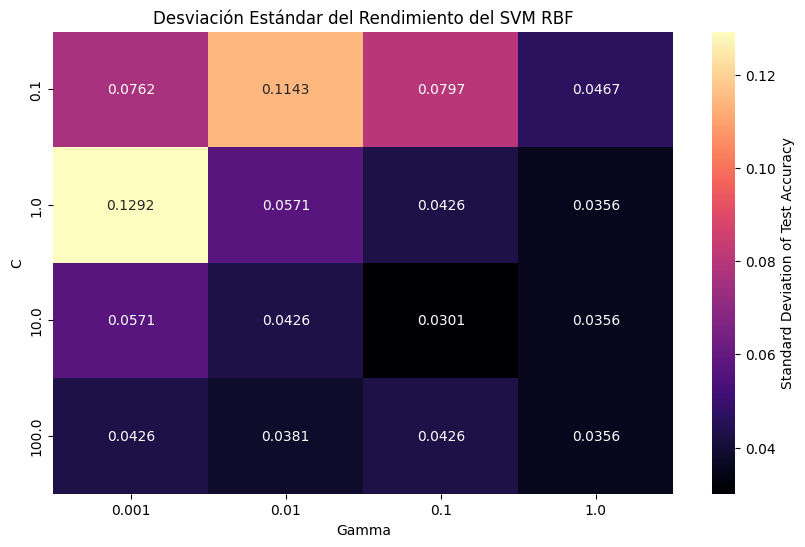

In [4]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns # Importar seaborn para las visualizaciones

# Cargar dataset Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- CAMBIOS: Optimización de SVM con kernel RBF y GridSearchCV ---
# Para una aplicación real, a menudo se prefiere un kernel no lineal como RBF
# y es crucial ajustar sus hiperparámetros (C y gamma) para un rendimiento óptimo.
# Esto también implicará un tiempo de entrenamiento más largo que un SVM lineal simple.

# Definir el modelo SVM con kernel RBF
modelo_svm_rbf = SVC(kernel='rbf', random_state=42)

# Definir la cuadrícula de parámetros a buscar
# C: Parámetro de regularización. Pequeños C = márgenes más amplios (más errores de clasificación).
#    Grandes C = márgenes más estrechos (menos errores de clasificación, riesgo de overfitting).
# gamma: Coeficiente del kernel. Determina la influencia de un solo ejemplo de entrenamiento.
#        Pequeños gamma = influencia lejana, grandes gamma = influencia cercana (riesgo de overfitting).
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# Configurar GridSearchCV para buscar la mejor combinación de hiperparámetros
# cv=5 indica validación cruzada de 5 pliegues.
print("Iniciando GridSearchCV para SVM RBF (esto tomará más tiempo)...\n")
grid_search = GridSearchCV(modelo_svm_rbf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Entrenar GridSearchCV
grid_search.fit(X_train, y_train)

# Mostrar los mejores parámetros y la mejor puntuación
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación de validación cruzada: {grid_search.best_score_:.4f}\n")

# Usar el mejor estimador para las predicciones
modelo_final_svm = grid_search.best_estimator_
y_pred = modelo_final_svm.predict(X_test)

# Evaluación del modelo final
print("Reporte de clasificación del SVM RBF optimizado:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusión del modelo final
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)

# --- Visualización de los resultados de GridSearchCV (Gráfica de Entrenamiento) ---
# Para entender cómo los hiperparámetros afectan el rendimiento.

results = pd.DataFrame(grid_search.cv_results_)

# Pivotar los resultados para crear una matriz de rendimiento para C y gamma
scores_mean = results.pivot_table(index='param_C', columns='param_gamma', values='mean_test_score')
scores_std = results.pivot_table(index='param_C', columns='param_gamma', values='std_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(scores_mean, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'Mean Test Accuracy'})
plt.title('Rendimiento del SVM RBF para diferentes C y Gamma')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(scores_std, annot=True, fmt=".4f", cmap="magma", cbar_kws={'label': 'Standard Deviation of Test Accuracy'})
plt.title('Desviación Estándar del Rendimiento del SVM RBF')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()